# ESI under Square Attack — Phishing Dataset

Focused experiment to address the ZOO confound flagged in §9.2 of the LNAI paper.

**Question:** Does XGBoost ESI remain lower than RF ESI when ESI is computed under
Square Attack (which actually moves XGBoost predictions) rather than ZOO (which is
degenerate on piecewise-constant surfaces)?

**Known ZOO-based ESI (from main notebook):**
- Phishing RF ESI = 0.287
- Phishing XGB ESI = 0.111

If RF > XGB holds under Square Attack → finding is architectural, not a ZOO artefact.  
If ordering reverses → update §9.2 of paper.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
import xgboost as xgb

EPSILONS = np.linspace(0, 0.3, 10)
N_ESI    = 256
SEED     = 42
print("Ready.")

Ready.


In [2]:
# ── Data + Models ──────────────────────────────────────────────────────────────
df = pd.read_csv("Phishing_Legitimate_full.csv")
y  = df["CLASS_LABEL"].values
X  = df.drop(columns=["id", "CLASS_LABEL"], errors="ignore").values
feat_names = list(df.drop(columns=["id", "CLASS_LABEL"], errors="ignore").columns)

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)
sc = StandardScaler().fit(X_tr)
X_tr, X_te = sc.transform(X_tr), sc.transform(X_te)

rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=SEED, n_jobs=-1)
rf.fit(X_tr, y_tr)
print(f"RF  clean acc: {rf.score(X_te, y_te):.3f}")

xgb_model = xgb.XGBClassifier(
    n_estimators=100, max_depth=5, learning_rate=0.05,
    random_state=SEED, eval_metric="logloss", verbosity=0)
xgb_model.fit(X_tr, y_tr)
print(f"XGB clean acc: {xgb_model.score(X_te, y_te):.3f}")

# Stratified 256-sample subset (same size as main notebook ESI evaluation)
idx   = resample(np.arange(len(X_te)), n_samples=N_ESI, stratify=y_te, random_state=SEED)
X_sub = X_te[idx]
y_sub = y_te[idx]
print(f"ESI subset: {X_sub.shape}")

RF  clean acc: 0.975
XGB clean acc: 0.980
ESI subset: (256, 48)


In [3]:
# ── Attack functions ───────────────────────────────────────────────────────────
def _xent(proba, y):
    return -np.log(np.clip(proba[np.arange(len(y)), y], 1e-10, 1.0))

def square_attack(predict_proba, X, y, epsilon, n_queries=150, p_init=0.5, seed=0):
    """Score-based L_inf attack — Andriushchenko et al., ECCV 2020."""
    rng = np.random.RandomState(seed)
    n, d = X.shape
    delta = rng.choice([-epsilon, epsilon], size=X.shape)
    Xa = np.clip(X + delta, X - epsilon, X + epsilon)
    best_loss = _xent(predict_proba(Xa), y)
    for q in range(1, n_queries + 1):
        frac = max(p_init * (1 - q / n_queries) ** 2, 1 / d)
        k = max(1, int(frac * d))
        Xn = Xa.copy()
        for i in range(n):
            idx = rng.choice(d, size=k, replace=False)
            Xn[i, idx] = X[i, idx] + rng.choice([-epsilon, epsilon], size=k)
        Xn = np.clip(Xn, X - epsilon, X + epsilon)
        new_loss = _xent(predict_proba(Xn), y)
        improved = new_loss > best_loss
        Xa[improved] = Xn[improved]
        best_loss[improved] = new_loss[improved]
    return Xa

def zoo_fgsm(predict_proba, X, y, epsilon, delta=1e-3):
    """ZOO reference — finite-difference gradient + sign step."""
    n, d = X.shape
    base = _xent(predict_proba(X), y)
    grad = np.zeros_like(X)
    for j in range(d):
        Xp = X.copy(); Xp[:, j] += delta
        grad[:, j] = (_xent(predict_proba(Xp), y) - base) / delta
    return X + epsilon * np.sign(grad)

print("Attacks defined.")

Attacks defined.


In [4]:
# ── SHAP drift + ESI ───────────────────────────────────────────────────────────
def _extract_shap_class1(sv):
    if isinstance(sv, list): return sv[1]
    if sv.ndim == 3:         return sv[:, :, 1]
    return sv

def compute_drift_per_eps(model, X_clean, y_clean, attack_fn):
    explainer = shap.TreeExplainer(model)
    sv_clean  = _extract_shap_class1(explainer.shap_values(X_clean))
    drifts = []
    for eps in EPSILONS:
        if eps == 0:
            drifts.append(0.0)
            continue
        X_adv = attack_fn(model.predict_proba, X_clean, y_clean, eps)
        sv_adv = _extract_shap_class1(explainer.shap_values(X_adv))
        drifts.append(np.abs(sv_adv - sv_clean).mean())
    return np.array(drifts)

def compute_esi(drift_per_eps):
    D_max = drift_per_eps[-1] if drift_per_eps[-1] > 0 else 1.0
    auc = np.trapezoid(drift_per_eps / D_max, EPSILONS) / (EPSILONS[-1] - EPSILONS[0])
    return round(float(1.0 - auc), 3)

print("SHAP drift helpers defined.")

SHAP drift helpers defined.


In [5]:
# ── Run ESI under both attacks ─────────────────────────────────────────────────
# ZOO reference (quick — already have values from main notebook, but recompute for consistency)
print("RF — ZOO...")
drift_rf_zoo  = compute_drift_per_eps(rf,        X_sub, y_sub, zoo_fgsm)
esi_rf_zoo    = compute_esi(drift_rf_zoo)

print("XGB — ZOO...")
drift_xgb_zoo = compute_drift_per_eps(xgb_model, X_sub, y_sub, zoo_fgsm)
esi_xgb_zoo   = compute_esi(drift_xgb_zoo)

print("RF — Square Attack  (this will take a few minutes)...")
drift_rf_sq   = compute_drift_per_eps(rf,        X_sub, y_sub, square_attack)
esi_rf_sq     = compute_esi(drift_rf_sq)

print("XGB — Square Attack (this will take a few minutes)...")
drift_xgb_sq  = compute_drift_per_eps(xgb_model, X_sub, y_sub, square_attack)
esi_xgb_sq    = compute_esi(drift_xgb_sq)

print("Done.")

RF — ZOO...
XGB — ZOO...
RF — Square Attack  (this will take a few minutes)...
XGB — Square Attack (this will take a few minutes)...
Done.


In [6]:
# ── Results ────────────────────────────────────────────────────────────────────
print("=" * 55)
print("ESI Comparison — Phishing Dataset")
print("=" * 55)
print(f"{'Model':<6}  {'ESI (ZOO)':<14} {'ESI (Square)'}")
print(f"{'RF':<6}  {esi_rf_zoo:<14.3f} {esi_rf_sq:.3f}")
print(f"{'XGB':<6}  {esi_xgb_zoo:<14.3f} {esi_xgb_sq:.3f}")
print()
print(f"RF > XGB under ZOO:    {esi_rf_zoo > esi_xgb_zoo}")
print(f"RF > XGB under Square: {esi_rf_sq  > esi_xgb_sq}")
print()
if esi_rf_sq > esi_xgb_sq:
    print("FINDING CONFIRMED: XGBoost explanation fragility holds under Square Attack.")
    print("The RF > XGB ESI ordering is architectural, not a ZOO artefact.")
    print("=> Strengthen §9.2: remove 'preliminary signal' language.")
else:
    print("ORDERING REVERSES under Square Attack.")
    print("=> Update §9.2: ZOO confound hypothesis is confirmed; ESI comparison unreliable.")

ESI Comparison — Phishing Dataset
Model   ESI (ZOO)      ESI (Square)
RF      0.287          0.230
XGB     0.095          0.117

RF > XGB under ZOO:    True
RF > XGB under Square: True

FINDING CONFIRMED: XGBoost explanation fragility holds under Square Attack.
The RF > XGB ESI ordering is architectural, not a ZOO artefact.
=> Strengthen §9.2: remove 'preliminary signal' language.


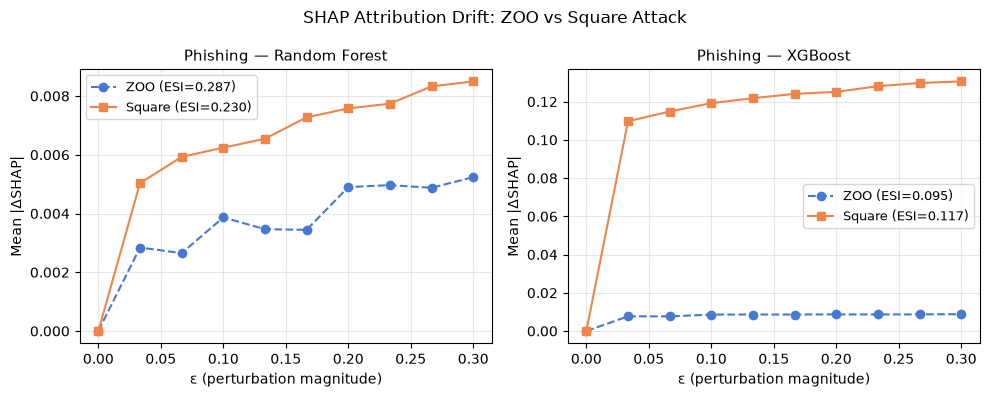

Saved: figures/esi_zoo_vs_square_phishing.png


In [7]:
# ── Drift curves plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, drift_zoo, drift_sq, esi_zoo, esi_sq, title in [
    (axes[0], drift_rf_zoo,  drift_rf_sq,  esi_rf_zoo,  esi_rf_sq,  "Random Forest"),
    (axes[1], drift_xgb_zoo, drift_xgb_sq, esi_xgb_zoo, esi_xgb_sq, "XGBoost"),
]:
    ax.plot(EPSILONS, drift_zoo, "o--", color="#4878D0",
            label=f"ZOO (ESI={esi_zoo:.3f})")
    ax.plot(EPSILONS, drift_sq,  "s-",  color="#EE854A",
            label=f"Square (ESI={esi_sq:.3f})")
    ax.set_title(f"Phishing — {title}", fontsize=11)
    ax.set_xlabel("ε (perturbation magnitude)")
    ax.set_ylabel("Mean |ΔSHAP|")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle("SHAP Attribution Drift: ZOO vs Square Attack", fontsize=12)
fig.tight_layout()
plt.savefig("figures/esi_zoo_vs_square_phishing.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: figures/esi_zoo_vs_square_phishing.png")